<a href="https://colab.research.google.com/github/deeeepak7/celebal_technology/blob/main/week3/week3_deepak_paliwal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem**:-

Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

**Resources :**

https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data

https://www.kaggle.com/code/jatin2bagga/unsupervised-learning-on-country-data/edit

# Downloading All Dependencies


In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans , DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score , accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

**Uploading Dataset in the colab notebook**

In [ ]:
df = pd.read_csv('/content/sample_data/Country-data.csv')

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# **Data Cleaning**

We do Data Cleaning to ensure that the Machine learning algorithm receive accurate , complete and properly scaled data which lead to meaningful and reliable result.

In [ ]:
print("the shape of the dataset is ",df.shape)
print("the columns are : " , df.columns)
df.info()

the shape of the dataset is  (167, 10)
the columns are :  Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


to handle duplicate columns

In [ ]:
print(f"the no. of duplicate row are : {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"the no. of duplicate row are : {df.duplicated().sum()}")


the no. of duplicate row are : 0
the no. of duplicate row are : 0


to handle whitespace

In [ ]:
df.columns = df.columns.str.strip()

Convert columns into numeric value

In [ ]:
for col in df.columns:
  if col != 'country':
    df[col] = pd.to_numeric(df[col], errors='coerce')

Filling Missing Value with Median

In [ ]:
for col in df.columns:
  if col != 'country':
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipykernel_703/1605207943.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isna().sum()


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


now we have cleaned the whole data all the unnecessary whitespace,any duplicate column were checked and removed , any missing value is replaced with median and all the columns apary from country are converted to numeric value and next step will be feature selection and scaling

# **Feature Scaling and  Scaling**

Machine learning algorithms such as K-Means and DBSCAN rely on numerical features to measure distances between data points. Since the country column is a categorical identifier, it does not contribute to the clustering process and is therefore removed.
then we will standardize the column using standardscaler which ensure the mean of each feature become 0 and standard deviation become 1,this prevent larger scal variable from dominating.




In [ ]:
countries = df['country']
X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [ ]:
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# **Elbow Method for Optimal Cluster Selection**

Before applying the K-Means clustering algorithm, it is important to determine the optimal number of clusters . The Elbow Method evaluates different values of k by calculating the Within-Cluster Sum of Squares (WCSS), also known as inertia.

The optimal value of k is identified at the point where the rate of decrease slows significantly, forming an elbow in the graph.


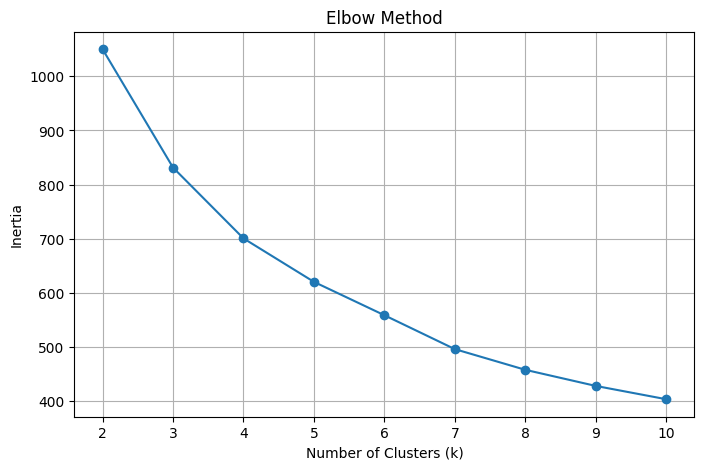

In [ ]:
inertia = []
for k in range(2, 11):
  kmeans = KMeans( n_clusters=k, random_state=42, n_init=10 )
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# **Conclusion**

from the graph we can see a bend at 3 .
Therefore, k = 3 is selected as the optimal number of clusters for the K-Means model, as it provides a good balance between minimizing within-cluster variance and maintaining a simple clustering structure.

# **K Mean Clustering**

K-Means is used to automatically divide similar data points into K groups by repeatedly assigning points to the nearest cluster center and updating those centers using the mean of the assigned points.

In [ ]:
best_k = 3
kmeans = KMeans( n_clusters=best_k, random_state=42, n_init=10 )
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [ ]:
print("Countries in each cluster:\n")
print(df['KMeans_Cluster'].value_counts().sort_index())

Countries in each cluster:

KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64


# **Cluster Evaluation using Silhouette Score**

The Silhouette Score is used to evaluate the quality of the clusters formed by the K-Means algorithm. It measures how similar a country is to its own cluster compared to other clusters.

The score ranges from -1 to 1:
- A value close to 1 indicates well-separated clusters.
- A value around 0 indicates overlapping clusters.
- A negative value suggests that observations may have been assigned to the wrong cluster.

In [ ]:
score = silhouette_score(X_scaled, kmeans_labels)
print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


Cluster Evaluation using Silhouette Score

The Silhouette Score obtained for the K-Means model is 0.2833.

Since the score lies between 0 and 0.5, it indicates that the clusters are only moderately separated and there is some overlap between them. The clustering structure exists, but it is not very strong or well-defined.

This suggests that:
- The countries have some similarities across different clusters.
- The selected value of k = 3 provides reasonable grouping, but the clusters are not perfectly distinct.

# **DBSCAN Model**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is an unsupervised machine learning clustering algorithm that groups data points based on their density. Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance and can identify clusters of arbitrary shapes.

DBSCAN uses two important parameters:

- eps (ε): The maximum distance between two points for them to be considered neighbors.
- min_samples: The minimum number of neighboring points required to form a dense region.



In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


# Principal Component Analysis (PCA) Visualization


The dataset contains multiple numerical features, making it difficult to visualize the clustering results directly. Principal Component Analysis (PCA) is applied to reduce the dimensionality of the dataset from nine features to two principal components while preserving as much variance as possible.

The transformed data is then visualized using a scatter plot, where each point represents a country and colors indicate the clusters assigned by the K-Means algorithm.

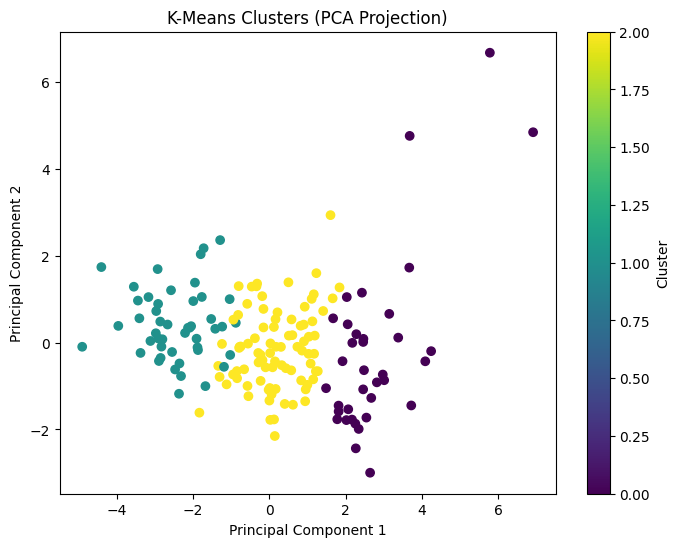

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
pca_df = pd.DataFrame(
    X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)
pca_df['Cluster'] = kmeans_labels
scatter = plt.scatter( X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis' )
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (PCA Projection)')
plt.colorbar(scatter, label='Cluster')
plt.show()

## Observations from PCA Visualization

1. The K-Means algorithm has divided the countries into three distinct clusters, represented by different colors in the PCA projection.

2. The purple cluster (Cluster 0) is relatively well separated from the other clusters, indicating that these countries have significantly different economic and social characteristics.

3. The yellow cluster (Cluster 2) lies near the center and shows some overlap with the other clusters, suggesting that these countries have intermediate characteristics and represent developing economies.

4. The teal cluster (Cluster 1) is concentrated on the left side of the plot and forms a separate group, indicating countries with similar low-income and high-mortality indicators.

5. A few points lie far away from the main groups, suggesting the presence of outlier countries with exceptionally high or low economic and development indicators.


# Cluster Analysis and Observations


In [ ]:
cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


## Conclusion

1. Cluster 1 represents low-development countries. It has the highest child mortality rate (92.96), the lowest income (3942.40), the lowest GDP per capita (1922.38), and the lowest life expectancy (59.19 years).

2. Cluster 0 represents highly developed countries. It has the highest income (45672.22), the highest GDP per capita (42494.44), the highest life expectancy (80.13 years), and the lowest child mortality rate (5.00).

3. Cluster 2 represents developing or emerging economies. Its economic and health indicators lie between Clusters 0 and 1, with moderate income (12305.60), GDP per capita (6486.45), and life expectancy (72.81 years).

4. Countries in Cluster 1 have the highest fertility rate (5.01) and relatively high inflation, indicating lower levels of economic and social development.

5. The clustering successfully separates countries into three major groups: developed economies, developing economies, and underdeveloped regions, based on economic, health, and demographic indicators.

# **Classification Models**

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0


In [ ]:
X = df.drop(["country","KMeans_Cluster","DBSCAN_Cluster"], axis=1)
Y = df["KMeans_Cluster"]
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
dt = DecisionTreeClassifier();
dt.fit(x_train,y_train)
dt_pred = dt.predict(x_test)
print("Decision Tree Accuracy: ",accuracy_score(y_test,dt_pred))


Decision Tree Accuracy:  1.0


# Ensemble Learning Algorithms

**Random Forest**

Trains many decision trees independently on different random samples and combines their predictions by voting (classification) .

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)
print("Random Forest Accuracy: ",accuracy_score(y_test,rf_pred))

Random Forest Accuracy:  1.0


**Adaboost**

Trains trees sequentially, giving more weight to previously misclassified samples so that the next tree focuses on difficult cases.

In [ ]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(x_train,y_train)
ada_pred = ada.predict(x_test)
print("AdaBoost Accuracy: ",accuracy_score(y_test,ada_pred))

AdaBoost Accuracy:  0.9705882352941176


 **XGBoost**

 Builds trees sequentially, where each new tree tries to correct the errors (residuals) of previous trees using gradient descent.

In [ ]:
xgb = XGBClassifier(random_state=42,eval_metric="mlogloss")
xgb.fit(x_train,y_train)
xgb_pred = xgb.predict(x_test)
print("XGBoost Accuracy: ",accuracy_score(y_test,xgb_pred))


XGBoost Accuracy:  0.9705882352941176


**LightBGM**

Similar to XGBoost but optimized for speed and memory using histogram-based splitting and leaf-wise tree growth.

In [ ]:
lgbm = LGBMClassifier(random_state=42,verbose=-1)
lgbm.fit(x_train,y_train)
lgbm_pred = lgbm.predict(x_test)
print("LGBM Accuracy: ",accuracy_score(y_test,lgbm_pred))

LGBM Accuracy:  0.9411764705882353


# Using Stack

where RandomForest and xgboost are base model and Logistic Regression as meta model

In [ ]:
estimator = [('rf',RandomForestClassifier(random_state = 42)),
 ('xgb',XGBClassifier(random_state = 42))]
stack = StackingClassifier(estimators=estimator,final_estimator=LogisticRegression())

In [ ]:
stack.fit(x_train,y_train)
stack_pred = stack.predict(x_test)
print("Stacking Accuracy: ",accuracy_score(y_test,stack_pred))

Stacking Accuracy:  1.0


# Observation Table

In [ ]:
result_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "AdaBoost", "XGBoost", "LGBM", "Stacking"],
    "Accuracy": [accuracy_score(y_test, dt_pred), accuracy_score(y_test, rf_pred), accuracy_score(y_test, ada_pred), accuracy_score(y_test, xgb_pred), accuracy_score(y_test, lgbm_pred), accuracy_score(y_test, stack_pred)]
})
result_table

,Model,Accuracy
0,Decision Tree,1.000000
1,Random Forest,1.000000
2,AdaBoost,0.970588
3,XGBoost,0.970588
4,LGBM,0.941176
5,Stacking,1.000000


# **Observation**

The classification models were trained to predict the cluster labels generated by K-Means clustering. Random Forest, Decision Tree, and the Stacking Classifier achieved an accuracy of 100%, indicating that the generated clusters are highly separable. AdaBoost and XGBoost achieved 97.06% accuracy, while LightGBM achieved 94.12%. These results suggest that the country clusters are well-defined and can be accurately predicted using supervised learning techniques.

# **Result**

As Decision tree got accuaracy of 100% we might have a overfit model but this doesn't mean the Model made using Random Forest is also overfit as it is a average of Decision trees.

Due to this we should select Stack of xgboost and Random Forest which gave 100% because different model make different error and combining their predictions through a meta-model can improve robustness and generalization compared to relying on a single classifier.